In [1]:
import numpy as np
import matplotlib.pyplot as plt
from MLmodels1pt import dilatedCNNModel, myLinearRegressionModel, myLogisticRegressionModel
from pathlib import Path

In [2]:
def mps_data(L, beta, q=1, weight=None):
    Zcorr = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zcorr_uniform_N10000_0_r.npy")
    # load <Z_r>_s, where each row corresponds to a different snapshot and each column corresponds to a different position r.
    Z = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_uniform_N10000_0_r.npy")
    _connected_corr = Zcorr - Z[:, :1] * Z
    if weight is not None:
        pr = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Pr_uniform_N10000_0_r.npy")
        pr /= np.sum(pr)
        print(pr)
        _connected_corr *= np.power(pr, weight).reshape(-1,1)
    return np.mean(np.power(np.abs(_connected_corr), q), axis=0), np.std(np.power(np.abs(_connected_corr), q), axis=0)/np.sqrt(Z.shape[0])

def ZexpZexp_mps_data(L, beta, q=1, weight=None):
    Zcorr = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zcorr_uniform_N10000_0_r.npy")
    # load <Z_r>_s, where each row corresponds to a different snapshot and each column corresponds to a different position r.
    Z = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_uniform_N10000_0_r.npy")
    _connected_corr = Z[:, :1] * Z
    return np.mean(np.power(_connected_corr, q), axis=0), np.std(np.power(_connected_corr, q), axis=0)/np.sqrt(Z.shape[0])

def ZexpZexp_ml_data(y_pred, q=1, weight=None):
    _connected_corr = y_pred[:, :1] * y_pred
    return np.mean(np.power(_connected_corr, q), axis=0), np.std(np.power(_connected_corr, q), axis=0)/np.sqrt(y_pred.shape[0])

In [6]:
x = np.arange(L)
x_chord = L / np.pi * np.sin(np.pi * x / L)
y = mps_data(L, beta, 1)

[1.61162092e-09 2.12015919e-09 6.24489834e-10 ... 4.82584746e-06
 3.47421023e-08 3.45585044e-07]


/tmp/ipykernel_543774/1198978188.py:8: RuntimeWarning: divide by zero encountered in power
  plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], "--", label=f"power law fit: slope={poly[0]:.2f}")


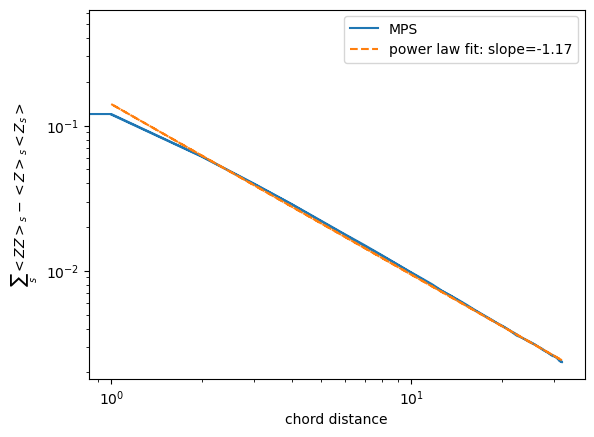

In [25]:
L = 100
beta = 0.5
x = np.arange(L)
x_chord = L / np.pi * np.sin(np.pi * x / L)
y = mps_data(L, beta, 1, weight=-0)
plt.loglog(x_chord, y[0], label="MPS")
poly = np.polyfit(np.log(x_chord[1:]), np.log(y[0][1:]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], "--", label=f"power law fit: slope={poly[0]:.2f}")
plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <ZZ>_s - <Z>_s <Z_s>$")
plt.legend()
plt.show()

/tmp/ipykernel_543774/2113970036.py:8: RuntimeWarning: divide by zero encountered in power
  plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], "--", label=f"power law fit: slope={poly[0]:.2f}")


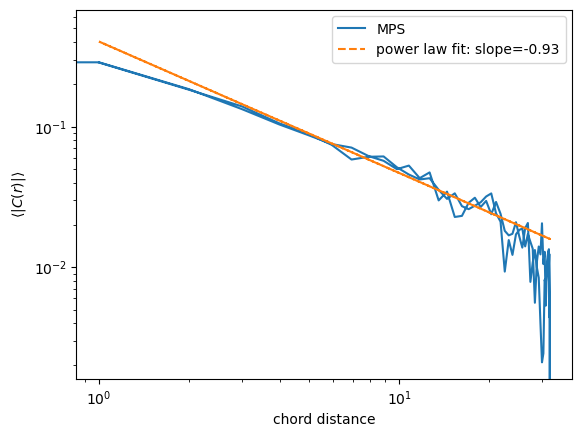

In [56]:
L = 100
beta = 0.5
x = np.arange(L)
x_chord = L / np.pi * np.sin(np.pi * x / L)
y = ZexpZexp_mps_data(L, beta, 1)
plt.loglog(x_chord, y[0], label="MPS")
poly = np.polyfit(np.log(x_chord[3:20]), np.log(y[0][3:20]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], "--", label=f"power law fit: slope={poly[0]:.2f}")
plt.xlabel("chord distance")
plt.ylabel(r"$\langle |C(r)| \rangle$")
plt.legend()
plt.show()

In [57]:
from pathlib import Path
save_dir = Path("../data")
cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N100000.pt"
cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")

In [61]:
x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
y_pred = cnn_model.predict_magnetization(x_input)

In [62]:
y_pred

array([[-0.7298788 , -0.7626776 , -0.68736756, ...,  0.80747366,
        -0.22841324,  0.4525671 ],
       [-0.8602432 ,  0.04676367, -0.67336607, ..., -0.7842552 ,
        -0.8951627 , -0.9212898 ],
       [-0.14039746,  0.75625145,  0.02601291, ..., -0.2228512 ,
        -0.3334832 ,  0.59485936],
       ...,
       [-0.15746924, -0.93534356, -0.96593   , ...,  0.3998029 ,
        -0.8495188 , -0.89876765],
       [-0.11459138, -0.08262525,  0.9055245 , ...,  0.19253299,
         0.92604107,  0.88591653],
       [-0.753132  ,  0.18510498, -0.6787542 , ..., -0.7243837 ,
         0.1946231 , -0.7665589 ]], shape=(10000, 100), dtype=float32)

In [63]:
def ZexpZexp_ml_data(y_pred, q=1, weight=None):
    _connected_corr = y_pred[:, :1] * y_pred
    return np.mean(np.power(_connected_corr, q), axis=0), np.std(np.power(_connected_corr, q), axis=0)/np.sqrt(y_pred.shape[0])

/tmp/ipykernel_568076/3132305354.py:20: RuntimeWarning: divide by zero encountered in power
  plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], "--", label=f"power law fit: slope={poly[0]:.2f}")


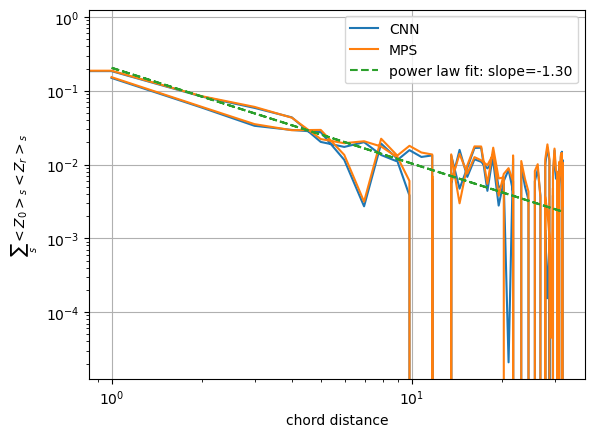

In [62]:
L = 100
beta = 0.8

save_dir = Path("../data")
cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N100000.pt"
cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
y_pred = cnn_model.predict_magnetization(x_input)

x = np.arange(L)
x_chord = L / np.pi * np.sin(np.pi * x / L)
y = ZexpZexp_ml_data(y_pred, q=1)
y0 = ZexpZexp_mps_data(L, beta, 1)[0]
plt.loglog(x_chord, y[0], label="CNN")
plt.loglog(x_chord, y0, label="MPS")
fit_start = 1
fit_end = 10

poly = np.polyfit(np.log(x_chord[fit_start:fit_end]), np.log(y[0][fit_start:fit_end]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], "--", label=f"power law fit: slope={poly[0]:.2f}")
plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_568076/1968234138.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(x_chord, 0.45*x_chord**(-1), "--", label=f"$\sim x^{{-1}}$", alpha=1)
/tmp/ipykernel_568076/1968234138.py:18: RuntimeWarning: divide by zero encountered in reciprocal
  plt.loglog(x_chord, 0.45*x_chord**(-1), "--", label=f"$\sim x^{{-1}}$", alpha=1)


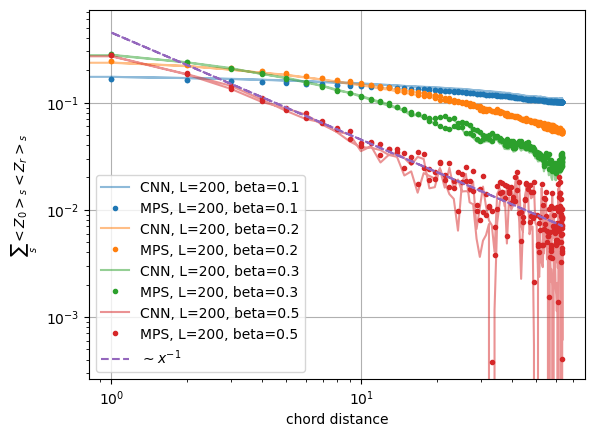

In [68]:
for L in [200]:
    for beta in [0.1, 0.2, 0.3, 0.5]:

        save_dir = Path("../data")
        cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N100000.pt"
        cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
        x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
        y_pred = cnn_model.predict_magnetization(x_input)

        x = np.arange(L)
        x_chord = L / np.pi * np.sin(np.pi * x / L)
        y = ZexpZexp_ml_data(y_pred, q=1)
        y0 = ZexpZexp_mps_data(L, beta, 1)[0]
        plt.loglog(x_chord, y[0], label=f"CNN, L={L}, beta={beta}", alpha=0.5)
        ax = plt.gca()
        c = ax.lines[-1].get_color()
        plt.loglog(x_chord, y0, '.', color=c, label=f"MPS, L={L}, beta={beta}")
plt.loglog(x_chord, 0.45*x_chord**(-1), "--", label=f"$\sim x^{{-1}}$", alpha=1)
plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()


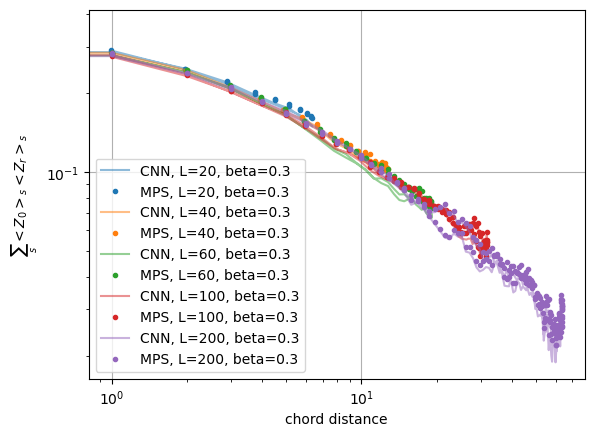

In [55]:
for L in [20, 40, 60, 100, 200]:
    for beta in [0.3]:

        save_dir = Path("../data")
        cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N100000.pt"
        cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
        x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
        y_pred = cnn_model.predict_magnetization(x_input)

        x = np.arange(L)
        x_chord = L / np.pi * np.sin(np.pi * x / L)
        y = ZexpZexp_ml_data(y_pred, q=1)
        y0 = ZexpZexp_mps_data(L, beta, 1)[0]
        plt.loglog(x_chord, y[0], label=f"CNN, L={L}, beta={beta}", alpha=0.5)
        ax = plt.gca()
        c = ax.lines[-1].get_color()
        plt.loglog(x_chord, y0, '.', color=c, label=f"MPS, L={L}, beta={beta}")

plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()


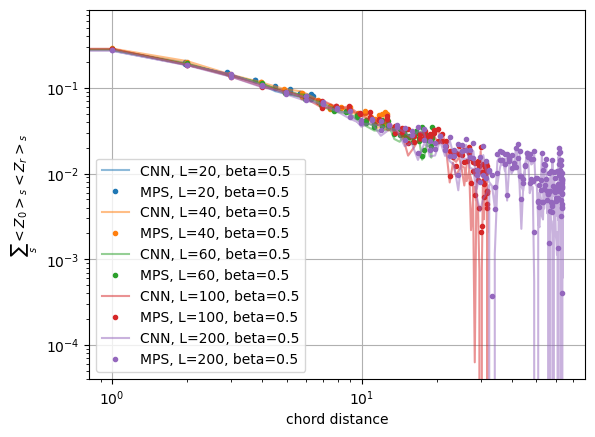

In [56]:
for L in [20, 40, 60, 100, 200]:
    for beta in [0.5]:

        save_dir = Path("../data")
        cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N100000.pt"
        cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
        x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
        y_pred = cnn_model.predict_magnetization(x_input)

        x = np.arange(L)
        x_chord = L / np.pi * np.sin(np.pi * x / L)
        y = ZexpZexp_ml_data(y_pred, q=1)
        y0 = ZexpZexp_mps_data(L, beta, 1)[0]
        plt.loglog(x_chord, y[0], label=f"CNN, L={L}, beta={beta}", alpha=0.5)
        ax = plt.gca()
        c = ax.lines[-1].get_color()
        plt.loglog(x_chord, y0, '.', color=c, label=f"MPS, L={L}, beta={beta}")

plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()


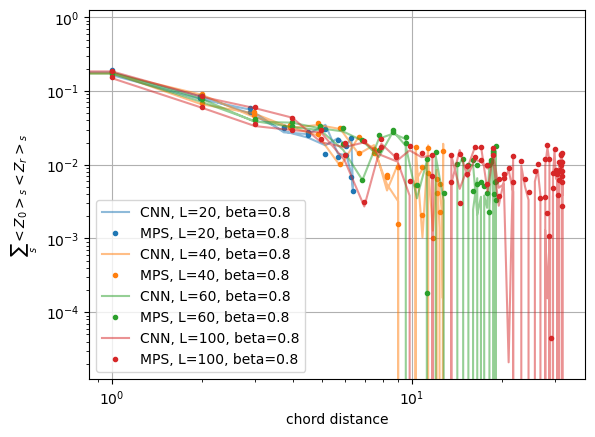

In [57]:
for L in [20, 40, 60, 100]:
    for beta in [0.8]:

        save_dir = Path("../data")
        cnn_path = save_dir / f"dilatedcnn_sharedpbc_L{L}_beta{beta}_N100000.pt"
        cnn_model = dilatedCNNModel.load(cnn_path, map_location="cpu")
        x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
        y_pred = cnn_model.predict_magnetization(x_input)

        x = np.arange(L)
        x_chord = L / np.pi * np.sin(np.pi * x / L)
        y = ZexpZexp_ml_data(y_pred, q=1)
        y0 = ZexpZexp_mps_data(L, beta, 1)[0]
        plt.loglog(x_chord, y[0], label=f"CNN, L={L}, beta={beta}", alpha=0.5)
        ax = plt.gca()
        c = ax.lines[-1].get_color()
        plt.loglog(x_chord, y0, '.', color=c, label=f"MPS, L={L}, beta={beta}")

plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()


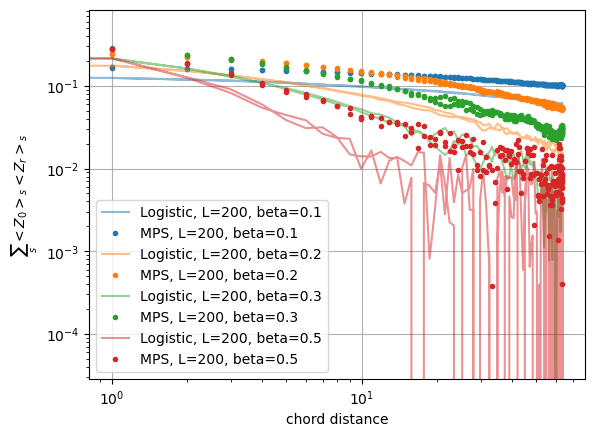

In [72]:
for L in [200]:
    for beta in [0.1, 0.2, 0.3, 0.5]:

        save_dir = Path("../data")
        cnn_path = save_dir / f"logistic_sharedpbc_L{L}_beta{beta}_N100000.pkl"
        cnn_model = myLogisticRegressionModel.load(cnn_path)
        x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
        y_pred = cnn_model.predict_magnetization(x_input)

        x = np.arange(L)
        x_chord = L / np.pi * np.sin(np.pi * x / L)
        y = ZexpZexp_ml_data(y_pred, q=1)
        y0 = ZexpZexp_mps_data(L, beta, 1)[0]
        plt.loglog(x_chord, y[0], label=f"Logistic, L={L}, beta={beta}", alpha=0.5)
        ax = plt.gca()
        c = ax.lines[-1].get_color()
        plt.loglog(x_chord, y0, '.', color=c, label=f"MPS, L={L}, beta={beta}")
# plt.loglog(x_chord, 0.45*x_chord**(-1), "--", label=f"$\sim x^{{-1}}$", alpha=1)
plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()


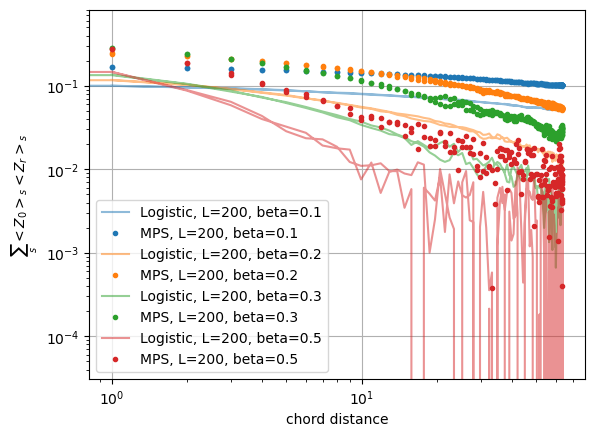

In [73]:
for L in [200]:
    for beta in [0.1, 0.2, 0.3, 0.5]:

        save_dir = Path("../data")
        cnn_path = save_dir / f"linear_sharedpbc_L{L}_beta{beta}_N100000.pkl"
        cnn_model = myLinearRegressionModel.load(cnn_path)
        x_input = np.load(f"../data/Uniform_L{L}_beta{beta}_N10000.npy")
        y_pred = cnn_model.predict_magnetization(x_input)

        x = np.arange(L)
        x_chord = L / np.pi * np.sin(np.pi * x / L)
        y = ZexpZexp_ml_data(y_pred, q=1)
        y0 = ZexpZexp_mps_data(L, beta, 1)[0]
        plt.loglog(x_chord, y[0], label=f"Logistic, L={L}, beta={beta}", alpha=0.5)
        ax = plt.gca()
        c = ax.lines[-1].get_color()
        plt.loglog(x_chord, y0, '.', color=c, label=f"MPS, L={L}, beta={beta}")
# plt.loglog(x_chord, 0.45*x_chord**(-1), "--", label=f"$\sim x^{{-1}}$", alpha=1)
plt.xlabel("chord distance")
plt.ylabel(r"$\sum_s <Z_0>_s <Z_r>_s$")
plt.legend()
# plt.ylim(1e-2, 1)
plt.grid()
plt.show()
